In [24]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [25]:
import quantstream as qs
import os
import xarray as xr
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import plotly.graph_objects as go

import sys

import dotenv


dotenv.load_dotenv("../.env")

sys.path.append("../")

FMP_API_KEY = os.getenv("FMP_API_KEY")

In [26]:
fmp = qs.FmpConnector(FMP_API_KEY)
data = fmp.get_intraday(
    symbol="NVDA",
    time_delta="5min",
    from_date="2023-02-01",
    to_date="2023-02-02",
)

In [27]:
data

<xarray.FinDataset> Size: 7kB
Dimensions:  (time: 156)
Coordinates:
  * time     (time) datetime64[ns] 1kB 2023-02-02T15:55:00 ... 2023-02-01T09:...
Data variables:
    open     (time) float64 1kB 21.66 21.51 21.5 21.51 ... 19.81 19.66 19.69
    low      (time) float64 1kB 21.62 21.5 21.47 21.45 ... 19.79 19.65 19.61
    high     (time) float64 1kB 21.75 21.67 21.53 21.56 ... 19.89 19.87 19.88
    close    (time) float64 1kB 21.72 21.66 21.5 21.5 ... 19.79 19.81 19.67
    volume   (time) int64 1kB 1499358 911354 424926 ... 1244523 1444246 1818253
Attributes:
    time_delta:  5min
    from_date:   2023-02-01
    to_date:     2023-02-02

In [28]:
df = data.to_dataframe()
df

,open,low,high,close,volume
time,,,,,
2023-02-02 15:55:00,21.65500,21.625,21.7460,21.72400,1499358
2023-02-02 15:50:00,21.50800,21.504,21.6710,21.65800,911354
2023-02-02 15:45:00,21.50200,21.466,21.5290,21.50300,424926
2023-02-02 15:40:00,21.51100,21.454,21.5568,21.50300,485702
2023-02-02 15:35:00,21.52800,21.496,21.5880,21.50900,638841
...,...,...,...,...,...
2023-02-01 09:50:00,19.87564,19.862,20.0100,20.00301,1570235
2023-02-01 09:45:00,19.79866,19.770,19.8950,19.87600,1012631
2023-02-01 09:40:00,19.81000,19.787,19.8900,19.79301,1244523


In [29]:
data_intraday = fmp.get_intraday(
    symbol="AAPL",
    time_delta="5min",
    from_date="2023-02-01",
    to_date="2023-02-02",
)
data_intraday.to_dataframe()

,open,low,high,close,volume
time,,,,,
2023-02-02 15:55:00,150.2100,150.1100,150.920,150.9200,3521530
2023-02-02 15:50:00,149.7000,149.7000,150.230,150.2200,2216696
2023-02-02 15:45:00,149.6700,149.4600,149.910,149.6950,1243864
2023-02-02 15:40:00,150.0700,149.6547,150.130,149.6600,1223690
2023-02-02 15:35:00,150.1900,149.9500,150.320,150.0650,1427698
...,...,...,...,...,...
2023-02-01 09:50:00,142.6150,142.5900,143.230,142.9900,1074525
2023-02-01 09:45:00,142.9597,142.5900,143.125,142.6268,995520
2023-02-01 09:40:00,142.9000,142.8500,143.300,142.9401,1039108


<Axes: xlabel='time'>

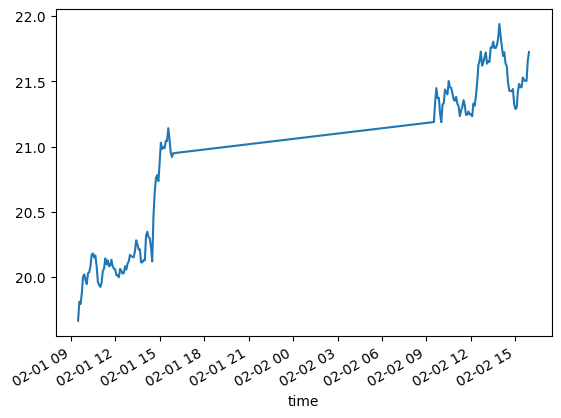

In [30]:
df["close"].plot()

In [31]:
portfolio = qs.Portfolio()
portfolio.add_security("NVDA")
portfolio.add_security("AAPL")
portfolio.add_security("TSLA")
portfolio.add_security("AMZN")

In [32]:
ds = portfolio.data['adjClose']

In [33]:
df = ds.to_dataframe()

In [34]:
# put securities as columns
df = df.unstack(level=0)

In [35]:
# drop the multiindex
df.columns = df.columns.droplevel()

<Axes: xlabel='time'>

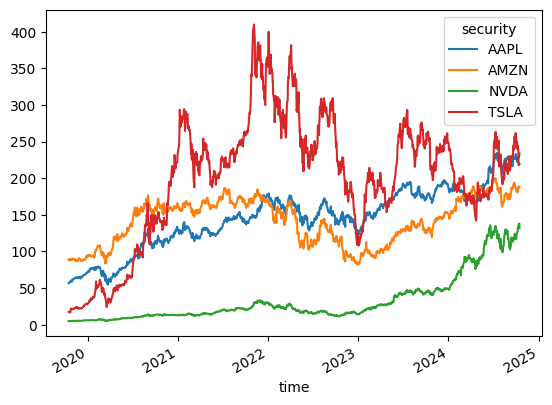

In [36]:
df.plot()

In [37]:
df

security,AAPL,AMZN,NVDA,TSLA
time,,,,
2019-10-16,56.70,88.87,4.83,17.32
2019-10-17,56.92,89.37,4.83,17.46
2019-10-18,57.19,87.88,4.74,17.13
2019-10-21,58.18,89.28,4.88,16.90
2019-10-22,58.05,88.29,4.87,17.04
...,...,...,...,...
2024-10-09,229.54,185.17,132.65,241.05
2024-10-10,229.04,186.65,134.81,238.77
2024-10-11,227.55,188.82,134.80,217.80


In [38]:
def generate_timeseries_json(df):
    json_data = {}
    for column in df.columns:
        json_data[column] = []
        for timestamp, value in df[column].iteritems():
            json_data[column].append({
                "timestamp": timestamp.isoformat(),
                "value": value
            })
    return json_data

 ### Changes Over Time

 - absolute changes
 - percentage change
 - log returns

In [39]:
vals = ds.values

In [40]:
df

security,AAPL,AMZN,NVDA,TSLA
time,,,,
2019-10-16,56.70,88.87,4.83,17.32
2019-10-17,56.92,89.37,4.83,17.46
2019-10-18,57.19,87.88,4.74,17.13
2019-10-21,58.18,89.28,4.88,16.90
2019-10-22,58.05,88.29,4.87,17.04
...,...,...,...,...
2024-10-09,229.54,185.17,132.65,241.05
2024-10-10,229.04,186.65,134.81,238.77
2024-10-11,227.55,188.82,134.80,217.80


In [41]:
# convert to dataframe
df.diff()

security,AAPL,AMZN,NVDA,TSLA
time,,,,
2019-10-16,NaN,NaN,NaN,NaN
2019-10-17,0.22,0.50,0.00,0.14
2019-10-18,0.27,-1.49,-0.09,-0.33
2019-10-21,0.99,1.40,0.14,-0.23
2019-10-22,-0.13,-0.99,-0.01,0.14
...,...,...,...,...
2024-10-09,3.77,2.45,-0.24,-3.45
2024-10-10,-0.50,1.48,2.16,-2.28
2024-10-11,-1.49,2.17,-0.01,-20.97


<Axes: xlabel='time'>

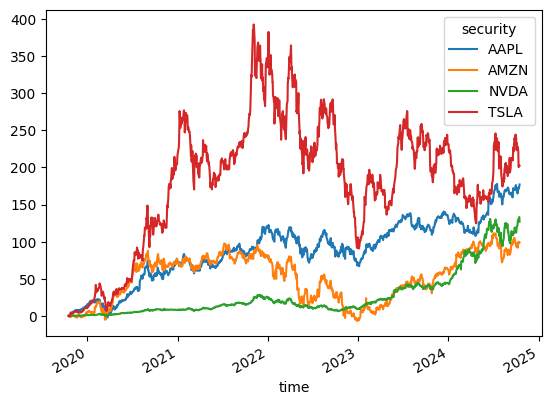

In [42]:
df.diff().cumsum().plot()

<Axes: xlabel='time'>

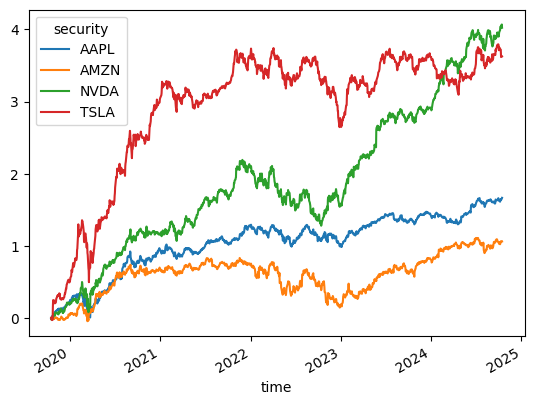

In [43]:
df.pct_change().cumsum().plot()

<Axes: xlabel='time'>

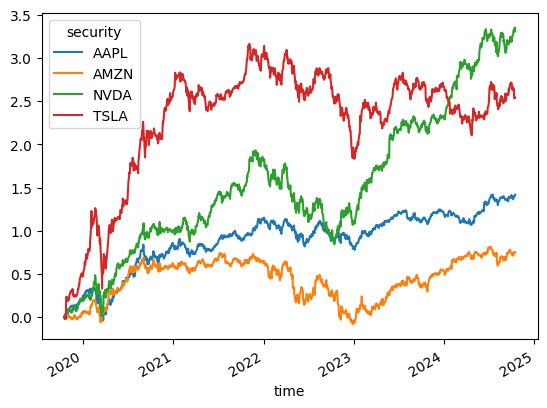

In [44]:
log_rets = np.log(df / df.shift(1))
log_rets.cumsum().plot()

<Axes: xlabel='time'>

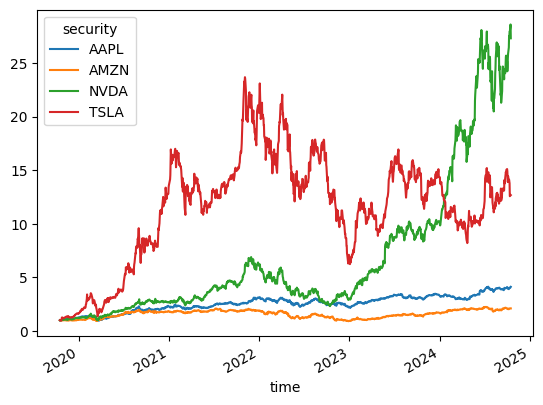

In [45]:
log_rets.cumsum().apply(np.exp).plot()